In [1]:
import sys
import os
import torch

In [2]:
# from federated_learning_cuda import load_configuration, main_experiment
from run import load_configuration, main_experiment

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   
from run import load_and_split_with_khop, load_and_split_with_feature_prop
dataset_name = "Cora"
num_clients = 10
beta = 1
hop = 1
data_loading_option = "full"
fulltraining_flag = False



In [4]:
cora_data = load_and_split_with_khop(dataset_name, device, num_clients, beta, hop=hop, imputation_method=data_loading_option, fulltraining_flag=fulltraining_flag)

In [5]:
len(cora_data)

4

In [6]:
# # check client 0 data
# print(clients_data[0])
# # check number of nodes in client 0 with zerof feature vectors
# # also check train/test/val nodes the number
# #total nodes in client 0
# total_nodes = clients_data[0].x.shape[0]
# #nodes with zero feature vectors
# zfv_nodes = torch.sum(clients_data[0].x == 0)
# print(f"Number of nodes in client 0 with zero feature vectors: {torch.sum(clients_data[0].x == 0)}")
# print(f"Number of train nodes in client 0: {torch.sum(clients_data[0].train_mask)}")
# print(f"Number of test nodes in client 0: {torch.sum(clients_data[0].test_mask)}")
# print(f"Number of val nodes in client 0: {torch.sum(clients_data[0].val_mask)}")




In [7]:
# load with fp and check the same things
data, dataset, clients_data, test_data,  = load_and_split_with_feature_prop("Citeseer", device, num_clients=10, beta=0.5, hop=1)

# check client 0 data
print(clients_data[0])
# check number of nodes in client 0 with zerof feature vectors
print(f"Number of nodes in client 0 with zero feature vectors: {torch.sum(clients_data[0].x == 0)}")
print(f"Number of train nodes in client 0: {torch.sum(clients_data[0].train_mask)}")
print(f"Number of test nodes in client 0: {torch.sum(clients_data[0].test_mask)}")
print(f"Number of val nodes in client 0: {torch.sum(clients_data[0].val_mask)}")
    


Data(x=[936, 3703], edge_index=[2, 2454], y=[936], train_mask=[936], val_mask=[936], test_mask=[936], mapping=[339])
Number of nodes in client 0 with zero feature vectors: 3281071
Number of train nodes in client 0: 7
Number of test nodes in client 0: 104
Number of val nodes in client 0: 55


In [8]:
import torch

print(f"Number of GPUs available: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
else:
    print("No GPU available")

Number of GPUs available: 1
GPU 0: NVIDIA L40-48Q


In [13]:
# from federated_learning_cuda import load_configuration, main_experiment
from run import load_configuration, main_experiment
import os
import ray
ray.shutdown()

if __name__ == "__main__":
    # Define all options in a list
    data_loading_options = ["full", "adjacency", "diffusion", ]
    model_types = ["GCN"]
        
    # Load configuration once since it's common for all runs
    clients_num, beta, cfg = load_configuration()

    beta = 1

    clients_num = 10

    results_dir = "results"

    # Main results directory
    exp_results_dir = 'Planetoid_results_non_iid'

    main_dir = os.path.join(results_dir, exp_results_dir)

    # loop through all the datasets
    datasets = ["Cora", "Citeseer", "Pubmed"]
    for dataset_name in datasets:
        # Loop over all combinations of data_loading_option and model_type
        for data_loading_option in data_loading_options:
            for model_type in model_types:
                # Create a structured directory for each experiment
                result_name = f"{dataset_name}_{data_loading_option}_{model_type}"
                results_dir = os.path.join(main_dir, result_name)

                # Create the directory if it doesn't exist
                os.makedirs(results_dir, exist_ok=True)

                print(f"Running experiment with data_loading_option: {data_loading_option}, model_type: {model_type}")
                result, output = main_experiment(clients_num, beta, data_loading_option, model_type, cfg, dataset_name=dataset_name, hop=1)
                
                # Replace literal '\n' with actual newline characters if necessary
                # Convert result dictionary to string representation first
                result_str = str(result)
                result_with_newlines = result_str.replace('\\n', '\n')
                
                # Create a unique filename for each combination
                filename = f'results_{dataset_name}_{data_loading_option}_{model_type}.txt'
                filepath = os.path.join(results_dir, filename)
                
                # Write the result to the text file
                with open(filepath, 'w') as f:
                    f.write(result_with_newlines)
                
                print(f"Results saved to {filepath}\n")

Running experiment with data_loading_option: full, model_type: GCN
DEVICE: cuda
Data loading option is full
Model type is GCN


2025-05-02 19:57:16,638	INFO worker.py:1816 -- Started a local Ray instance.


data_loading_option: full
Data loaded
Device is cuda
Cora()
10


(FLClient pid=2832023) 2025-05-02 19:57:22,485 - INFO - Epoch   0| Train Loss: 1.937| Train Accuracy: 0.077
(FLClient pid=2832023) 2025-05-02 19:57:22,489 - INFO - Epoch   1| Train Loss: 1.748| Train Accuracy: 0.462
(FLClient pid=2832023) 2025-05-02 19:57:22,494 - INFO - Epoch   2| Train Loss: 1.625| Train Accuracy: 0.615
(FLClient pid=2832023) 2025-05-02 19:57:22,504 - INFO - Epoch   2| Validation Loss: 2.000, Validation Accuracy: 0.000
(FLClient pid=2832023) 2025-05-02 19:57:27,796 - INFO - Epoch   2| Train Loss: 0.412| Train Accuracy: 0.923 [repeated 450x across cluster]
(FLClient pid=2832023) 2025-05-02 19:57:27,804 - INFO - Epoch   2| Validation Loss: 1.113, Validation Accuracy: 0.705 [repeated 150x across cluster]
(FLClient pid=2832023) 2025-05-02 19:57:32,873 - INFO - Epoch   1| Train Loss: 0.182| Train Accuracy: 1.000 [repeated 449x across cluster]
(FLClient pid=2832022) 2025-05-02 19:57:32,553 - INFO - Epoch   2| Validation Loss: 0.823, Validation Accuracy: 0.711 [repeated 149

Training done
Round 1
Train Loss: 1.311, Train Accuracy: 0.542
Train Loss: 2.000, Train Accuracy: 0.615
Train Loss: 1.517, Train Accuracy: 0.636
Train Loss: 1.482, Train Accuracy: 0.778
Train Loss: 1.573, Train Accuracy: 0.625
Train Loss: 1.740, Train Accuracy: 0.417
Train Loss: 1.816, Train Accuracy: 0.846
Train Loss: 1.694, Train Accuracy: 0.800
Train Loss: 1.675, Train Accuracy: 0.409
Train Loss: 1.782, Train Accuracy: 0.400
Round 2
Train Loss: 1.224, Train Accuracy: 0.667
Train Loss: 2.024, Train Accuracy: 0.462
Train Loss: 1.397, Train Accuracy: 0.727
Train Loss: 1.468, Train Accuracy: 0.778
Train Loss: 1.488, Train Accuracy: 0.688
Train Loss: 1.617, Train Accuracy: 0.667
Train Loss: 1.739, Train Accuracy: 0.692
Train Loss: 1.618, Train Accuracy: 0.800
Train Loss: 1.568, Train Accuracy: 0.500
Train Loss: 1.741, Train Accuracy: 0.400
Round 3
Train Loss: 1.157, Train Accuracy: 0.625
Train Loss: 1.883, Train Accuracy: 0.615
Train Loss: 1.304, Train Accuracy: 0.727
Train Loss: 1.467, 

...

Training done
Round 1
Train Loss: 0.565, Train Accuracy: 1.000
Train Loss: 0.879, Train Accuracy: 0.571
Train Loss: 1.078, Train Accuracy: 0.800
Train Loss: 2.278, Train Accuracy: 1.000
Train Loss: 1.157, Train Accuracy: 0.500
Train Loss: 0.395, Train Accuracy: 1.000
Train Loss: 1.222, Train Accuracy: 0.667
Train Loss: 0.626, Train Accuracy: 0.909
Train Loss: 1.189, Train Accuracy: 0.700
Train Loss: 1.089, Train Accuracy: 0.500
Round 2
Train Loss: 0.569, Train Accuracy: 1.000
Train Loss: 0.884, Train Accuracy: 0.571
Train Loss: 1.048, Train Accuracy: 0.800
Train Loss: 2.484, Train Accuracy: 1.000
Train Loss: 1.167, Train Accuracy: 0.500
Train Loss: 0.407, Train Accuracy: 1.000
Train Loss: 1.282, Train Accuracy: 0.667
Train Loss: 0.635, Train Accuracy: 0.909
Train Loss: 1.238, Train Accuracy: 0.700
Train Loss: 1.098, Train Accuracy: 0.500
Round 3
Train Loss: 0.574, Train Accuracy: 1.000
Train Loss: 0.907, Train Accuracy: 0.571
Train Loss: 1.099, Train Accuracy: 0.800
Train Loss: 2.822, 

(FLClient pid=2853936) 2025-05-02 20:10:06,496 - INFO - Epoch   2| Train Loss: 0.397| Train Accuracy: 1.000 [repeated 360x across cluster]
(FLClient pid=2853936) 2025-05-02 20:10:06,505 - INFO - Epoch   2| Validation Loss: 0.634, Validation Accuracy: 0.833 [repeated 120x across cluster]
(FLClient pid=2853936) 2025-05-02 20:10:11,471 - INFO - Epoch   2| Train Loss: 0.257| Train Accuracy: 1.000 [repeated 360x across cluster]
(FLClient pid=2853936) 2025-05-02 20:10:11,478 - INFO - Epoch   2| Validation Loss: 0.641, Validation Accuracy: 0.833 [repeated 120x across cluster]
(FLClient pid=2853933) 2025-05-02 20:10:16,562 - INFO - Epoch   0| Train Loss: 1.099| Train Accuracy: 0.000 [repeated 448x across cluster]
(FLClient pid=2853943) 2025-05-02 20:10:16,254 - INFO - Epoch   2| Validation Loss: 0.958, Validation Accuracy: 0.645 [repeated 149x across cluster]
(FLClient pid=2853936) 2025-05-02 20:10:21,693 - INFO - Epoch   2| Train Loss: 0.161| Train Accuracy: 1.000 [repeated 452x across cluste

Training done
Round 1
Train Loss: 0.634, Train Accuracy: 1.000
Train Loss: 0.966, Train Accuracy: 0.571
Train Loss: 1.031, Train Accuracy: 0.800
Train Loss: 2.067, Train Accuracy: 1.000
Train Loss: 1.137, Train Accuracy: 0.500
Train Loss: 0.416, Train Accuracy: 1.000
Train Loss: 1.293, Train Accuracy: 0.667
Train Loss: 0.643, Train Accuracy: 0.909
Train Loss: 1.155, Train Accuracy: 0.700
Train Loss: 1.090, Train Accuracy: 0.500
Round 2
Train Loss: 0.632, Train Accuracy: 1.000
Train Loss: 0.977, Train Accuracy: 0.571
Train Loss: 1.047, Train Accuracy: 0.800
Train Loss: 2.484, Train Accuracy: 1.000
Train Loss: 1.198, Train Accuracy: 0.667
Train Loss: 0.427, Train Accuracy: 1.000
Train Loss: 1.339, Train Accuracy: 0.667
Train Loss: 0.650, Train Accuracy: 0.909
Train Loss: 1.233, Train Accuracy: 0.700
Train Loss: 1.102, Train Accuracy: 0.500
Round 3
Train Loss: 0.634, Train Accuracy: 1.000
Train Loss: 0.996, Train Accuracy: 0.571
Train Loss: 1.081, Train Accuracy: 0.800
Train Loss: 2.560, 

(FLClient pid=2853939) 2025-05-02 20:10:41,150 - INFO - Epoch   2| Train Loss: 0.464| Train Accuracy: 0.800 [repeated 387x across cluster]
(FLClient pid=2853939) 2025-05-02 20:10:41,155 - INFO - Epoch   2| Validation Loss: 1.285, Validation Accuracy: 0.404 [repeated 129x across cluster]


Results saved to results/Planetoid_results_non_iid/Pubmed_diffusion_GCN/results_Pubmed_diffusion_GCN.txt



In [ ]:
# # from federated_learning_cuda import load_configuration, main_experiment
# from run import load_configuration, main_experiment
# import os
# import ray
# ray.shutdown()

# if __name__ == "__main__":
#     # Define all options in a list
#     data_loading_options = ["full", "adjacency", "diffusion", ]
#     model_types = ["GCN"]
        
#     # Load configuration once since it's common for all runs
#     clients_num, beta, cfg = load_configuration()

#     beta = 10000

#     clients_num = 10

#     # Main results directory
#     main_dir = 'Pubmed_results474'
#     dataset_name = "Pubmed"  # You can change this if you have different datasets

#     # Loop over all combinations of data_loading_option and model_type
#     for data_loading_option in data_loading_options:
#         for model_type in model_types:
#             # Create a structured directory for each experiment
#             result_name = f"{dataset_name}_{data_loading_option}_{model_type}"
#             results_dir = os.path.join(main_dir, result_name)

#             # Create the directory if it doesn't exist
#             os.makedirs(results_dir, exist_ok=True)

#             print(f"Running experiment with data_loading_option: {data_loading_option}, model_type: {model_type}")
#             result, output = main_experiment(clients_num, beta, data_loading_option, model_type, cfg, dataset_name=dataset_name, hop=1)
            
#             # Replace literal '\n' with actual newline characters if necessary
#             # Convert result dictionary to string representation first
#             result_str = str(result)
#             result_with_newlines = result_str.replace('\\n', '\n')
            
#             # Create a unique filename for each combination
#             filename = f'results_{dataset_name}_{data_loading_option}_{model_type}.txt'
#             filepath = os.path.join(results_dir, filename)
            
#             # Write the result to the text file
#             with open(filepath, 'w') as f:
#                 f.write(result_with_newlines)
            
#             print(f"Results saved to {filepath}\n")

In [14]:
import os
import ast # To safely evaluate string literal as dictionary
import pandas as pd
import logging # Using logging for better error reporting

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

def process_results_folder(main_folder_path):
    """
    Processes experiment results stored in subfolders of a main directory.

    Reads .txt files containing dictionary-like strings, parses them,
    and organizes the configuration and summary data into a Pandas DataFrame.

    Args:
        main_folder_path (str): The path to the main results folder
                                (e.g., 'Central_results2').

    Returns:
        pandas.DataFrame: A DataFrame containing the structured results,
                          with each row representing an experiment.
                          Returns an empty DataFrame if the folder is not found
                          or no valid results are processed.
    """
    all_results_data = [] # List to hold data for each valid experiment

    # --- Input Validation ---
    if not os.path.isdir(main_folder_path):
        logging.error(f"Folder not found at '{main_folder_path}'")
        return pd.DataFrame() # Return empty DataFrame

    logging.info(f"Starting processing for folder: '{main_folder_path}'")

    # --- Iterate Through Subfolders ---
    try:
        subfolder_names = os.listdir(main_folder_path)
    except OSError as e:
        logging.error(f"Could not list directory contents for '{main_folder_path}': {e}")
        return pd.DataFrame()

    for item_name in subfolder_names:
        subfolder_path = os.path.join(main_folder_path, item_name)

        # Check if it's actually a directory
        if not os.path.isdir(subfolder_path):
            logging.debug(f"Skipping non-directory item: '{item_name}'")
            continue

        logging.info(f"Processing subfolder: '{item_name}'")

        # --- Find the .txt File ---
        txt_file_path = None
        try:
            files_in_subfolder = os.listdir(subfolder_path)
            for filename in files_in_subfolder:
                if filename.endswith(".txt"):
                    # Assume only one relevant .txt file per subfolder
                    txt_file_path = os.path.join(subfolder_path, filename)
                    logging.debug(f"Found results file: '{filename}'")
                    break # Stop searching in this subfolder once found
            if not txt_file_path:
                 logging.warning(f"No .txt file found in subfolder '{item_name}'. Skipping.")
                 continue
        except OSError as e:
            logging.warning(f"Could not list files in subfolder '{item_name}': {e}. Skipping.")
            continue

        # --- Read and Parse File Content ---
        try:
            with open(txt_file_path, 'r', encoding='utf-8') as f:
                content = f.read()

            # Safely parse the string content into a Python dictionary
            # ast.literal_eval is safer than eval() for untrusted input
            data = ast.literal_eval(content)

            if not isinstance(data, dict):
                 logging.warning(f"Parsed content from '{txt_file_path}' is not a dictionary. Skipping.")
                 continue

        except FileNotFoundError:
            # This might happen in rare race conditions if the file is deleted
            # between listing and opening
            logging.warning(f"File '{txt_file_path}' found initially but could not be opened. Skipping.")
            continue
        except (SyntaxError, ValueError) as e:
            logging.warning(f"Error parsing content in file '{txt_file_path}': {e}. Skipping.")
            continue
        except Exception as e:
            logging.error(f"An unexpected error occurred reading/parsing '{txt_file_path}': {e}. Skipping.")
            continue

        # --- Extract Data ---
        # Use .get() for safer access in case keys are missing
        config = data.get('experiment_config', {})
        summary = data.get('summary', {})

        if not config or not summary:
             logging.warning(f"Missing 'experiment_config' or 'summary' key in '{txt_file_path}'. Skipping file.")
             continue

        # Create a flat dictionary for the DataFrame row
        # Start with configuration parameters
        row_data = config.copy()

        # Add summary results, prefixing keys if needed to avoid clashes (optional)
        # Example: prefix summary keys with 'summary_'
        # summary_prefixed = {f'summary_{k}': v for k, v in summary.items()}
        # row_data.update(summary_prefixed)

        # Or just update directly if keys are distinct
        row_data.update(summary)

        # Add an identifier for the experiment (using subfolder name)
        row_data['experiment_id'] = item_name
        # You could also add the filename if needed:
        # row_data['source_file'] = os.path.basename(txt_file_path)

        # Remove potentially large list/dict columns if not needed directly in the summary table
        # Adjust these based on what you want in the final table
        row_data.pop('global_results', None) # Remove list of all global results per round
        row_data.pop('client_results', None) # Remove list of all client results per round
        row_data.pop('rounds', None)         # Remove the detailed rounds data

        all_results_data.append(row_data)
        logging.debug(f"Successfully processed data for experiment '{item_name}'")

    # --- Create DataFrame ---
    if not all_results_data:
        logging.warning("No valid experiment data found to create a DataFrame.")
        return pd.DataFrame()

    try:
        results_df = pd.DataFrame(all_results_data)
        logging.info(f"Successfully created DataFrame with {len(results_df)} rows.")

        # Optional: Reorder columns for better readability
        id_col = ['experiment_id']
        config_cols = list(data.get('experiment_config', {}).keys())
        summary_cols = list(k for k in data.get('summary', {}).keys() if k not in ['global_results', 'client_results']) # Get summary keys added
        # Filter out columns that might not exist in all rows if parsing failed partially
        existing_cols = [col for col in id_col + config_cols + summary_cols if col in results_df.columns]
        results_df = results_df[existing_cols]

        # Optional: Set experiment_id as the DataFrame index
        # results_df.set_index('experiment_id', inplace=True)

    except Exception as e:
        logging.error(f"Failed to create DataFrame from processed data: {e}")
        return pd.DataFrame()


    return results_df

# --- Example Usage ---
# Note: Replace 'Central_results2' with the actual path to your folder.
# If running this script, make sure the folder exists relative to the script
# or provide an absolute path.

# Create dummy structure for demonstration if needed
def create_dummy_structure(base_dir="Central_results2_demo"):
    if not os.path.exists(base_dir):
        os.makedirs(base_dir)
    # Sample data similar to the user's example
    experiments_data = {
        "Pubmed_adjacency_GCN": {'experiment_config': {'device': 'cuda', 'data_loading_option': 'adjacency', 'model_type': 'GCN', 'dataset': 'Pubmed', 'num_clients': 10, 'beta': 1, 'hop': 1, 'fulltraining_flag': False}, 'rounds': [{'round': 1, 'global_result': 0.715, 'client_result': 0.724}, {'round': 2, 'global_result': 0.67, 'client_result': 0.698}], 'summary': {'global_results': [0.715, 0.67], 'client_results': [0.724, 0.698], 'average_global_result': 0.6925, 'average_client_result': 0.711, 'std_global': 0.0225, 'std_client': 0.013}},
        "Pubmed_diffusion_GCN": {'experiment_config': {'device': 'cuda', 'data_loading_option': 'diffusion', 'model_type': 'GCN', 'dataset': 'Pubmed', 'num_clients': 10, 'beta': 1, 'hop': 2, 'fulltraining_flag': False}, 'rounds': [], 'summary': {'average_global_result': 0.701, 'average_client_result': 0.715, 'std_global': 0.021, 'std_client': 0.012}},
        "Cora_full_SAGE": {'experiment_config': {'device': 'cpu', 'data_loading_option': 'full', 'model_type': 'SAGE', 'dataset': 'Cora', 'num_clients': 1, 'beta': 0, 'hop': 0, 'fulltraining_flag': True}, 'rounds': [], 'summary': {'average_global_result': 0.81, 'average_client_result': 0.81, 'std_global': 0.0, 'std_client': 0.0}},
        "Folder_With_Invalid_Txt": "This is not a dictionary string", # Test invalid content
        "Folder_With_No_Txt": {}, # Test missing txt file
        "Folder_With_Missing_Keys": {'experiment_config': {'device': 'cpu'}, 'summary': {}} # Test missing keys
    }
    logging.info(f"Creating dummy structure in '{base_dir}'...")
    for folder_name, data in experiments_data.items():
        subfolder_path = os.path.join(base_dir, folder_name)
        if not os.path.exists(subfolder_path):
            os.makedirs(subfolder_path)

        if folder_name == "Folder_With_No_Txt":
            # Create an empty file or a file with a different extension
            with open(os.path.join(subfolder_path, "other_file.log"), 'w') as f:
                f.write("Log data")
            continue # Don't create the specific .txt file

        # Create the results text file
        txt_filename = f"results_{folder_name}.txt"
        txt_filepath = os.path.join(subfolder_path, txt_filename)
        try:
            with open(txt_filepath, 'w', encoding='utf-8') as f:
                if isinstance(data, dict):
                    # Convert dict to string representation for the file
                    f.write(str(data))
                else:
                    # Write invalid data directly
                    f.write(data)
        except IOError as e:
            logging.error(f"Failed to write dummy file {txt_filepath}: {e}")
    logging.info("Dummy structure created.")


# --- Main execution block ---
if __name__ == "__main__":
    # Create dummy data for testing
    dummy_folder_path = "Central_results2_demo"
    create_dummy_structure(dummy_folder_path)

    # Process the results folder
    results_dataframe = process_results_folder(dummy_folder_path)

    # Display the results
    if not results_dataframe.empty:
        print("\n--- Processed Results DataFrame ---")
        # Configure pandas display options for better readability
        pd.set_option('display.max_columns', None) # Show all columns
        pd.set_option('display.width', 1000)       # Adjust width
        print(results_dataframe)
    else:
        print("\nNo DataFrame was generated. Check log messages for details.")

    # Clean up dummy structure (optional)
    # import shutil
    # try:
    #     shutil.rmtree(dummy_folder_path)
    #     logging.info(f"Cleaned up dummy directory: '{dummy_folder_path}'")
    # except OSError as e:
    #     logging.error(f"Error removing dummy directory '{dummy_folder_path}': {e}")


2025-05-02 20:11:11,700 - INFO - Creating dummy structure in 'Central_results2_demo'...
2025-05-02 20:11:11,701 - INFO - Dummy structure created.
2025-05-02 20:11:11,702 - INFO - Starting processing for folder: 'Central_results2_demo'
2025-05-02 20:11:11,702 - INFO - Processing subfolder: 'Folder_With_Missing_Keys'
2025-05-02 20:11:11,703 - WARNING - Missing 'experiment_config' or 'summary' key in 'Central_results2_demo/Folder_With_Missing_Keys/results_Folder_With_Missing_Keys.txt'. Skipping file.
2025-05-02 20:11:11,703 - INFO - Processing subfolder: 'Folder_With_No_Txt'
2025-05-02 20:11:11,704 - WARNING - No .txt file found in subfolder 'Folder_With_No_Txt'. Skipping.
2025-05-02 20:11:11,704 - INFO - Processing subfolder: 'Folder_With_Invalid_Txt'
2025-05-02 20:11:11,704 - WARNING - Error parsing content in file 'Central_results2_demo/Folder_With_Invalid_Txt/results_Folder_With_Invalid_Txt.txt': invalid syntax (<unknown>, line 1). Skipping.
2025-05-02 20:11:11,705 - INFO - Processing


--- Processed Results DataFrame ---
          experiment_id device data_loading_option model_type dataset  num_clients  beta  hop  fulltraining_flag  average_global_result  average_client_result  std_global  std_client
0        Cora_full_SAGE    cpu                full       SAGE    Cora            1     0    0               True                 0.8100                  0.810      0.0000       0.000
1  Pubmed_adjacency_GCN   cuda           adjacency        GCN  Pubmed           10     1    1              False                 0.6925                  0.711      0.0225       0.013
2  Pubmed_diffusion_GCN   cuda           diffusion        GCN  Pubmed           10     1    2              False                 0.7010                  0.715      0.0210       0.012


In [15]:
results_iid = "/home/brian_bosho/FP/FP/federated-gnn/src/results/Planetoid_results"
df_iid = process_results_folder(results_iid)
df_iid

2025-05-02 20:12:16,963 - INFO - Starting processing for folder: '/home/brian_bosho/FP/FP/federated-gnn/src/results/Planetoid_results'
2025-05-02 20:12:16,965 - INFO - Processing subfolder: 'Cora_adjacency_GCN'
2025-05-02 20:12:16,965 - INFO - Processing subfolder: 'Citeseer_adjacency_GCN'
2025-05-02 20:12:16,966 - INFO - Processing subfolder: 'Citeseer_diffusion_GCN'
2025-05-02 20:12:16,967 - INFO - Processing subfolder: 'Cora_full_GCN'
2025-05-02 20:12:16,967 - INFO - Processing subfolder: 'Pubmed_full_GCN'
2025-05-02 20:12:16,968 - INFO - Processing subfolder: 'Citeseer_full_GCN'
2025-05-02 20:12:16,968 - INFO - Processing subfolder: 'Pubmed_adjacency_GCN'
2025-05-02 20:12:16,969 - INFO - Processing subfolder: 'Cora_diffusion_GCN'
2025-05-02 20:12:16,970 - INFO - Processing subfolder: 'Pubmed_diffusion_GCN'
2025-05-02 20:12:16,971 - INFO - Successfully created DataFrame with 9 rows.


,experiment_id,device,data_loading_option,model_type,dataset,num_clients,beta,hop,fulltraining_flag,average_global_result,average_client_result,std_global,std_client
0,Cora_adjacency_GCN,cuda,adjacency,GCN,Cora,10,10000,1,False,0.7885,0.716492,0.0015,0.012905
1,Citeseer_adjacency_GCN,cuda,adjacency,GCN,Citeseer,10,10000,1,False,0.6800,0.640979,0.0020,0.000616
2,Citeseer_diffusion_GCN,cuda,diffusion,GCN,Citeseer,10,10000,1,False,0.6890,0.654793,0.0030,0.006544
3,Cora_full_GCN,cuda,full,GCN,Cora,10,10000,1,False,0.8090,0.805194,0.0040,0.005128
4,Pubmed_full_GCN,cuda,full,GCN,Pubmed,10,10000,1,False,0.6600,0.646864,0.0580,0.067597
5,Citeseer_full_GCN,cuda,full,GCN,Citeseer,10,10000,1,False,0.7020,0.689771,0.0020,0.003579
6,Pubmed_adjacency_GCN,cuda,adjacency,GCN,Pubmed,10,10000,1,False,0.6640,0.647852,0.0770,0.082501
7,Cora_diffusion_GCN,cuda,diffusion,GCN,Cora,10,10000,1,False,0.7895,0.732233,0.0045,0.006205
8,Pubmed_diffusion_GCN,cuda,diffusion,GCN,Pubmed,10,10000,1,False,0.7120,0.727544,0.0500,0.056642


In [16]:
results_noniid = "/home/brian_bosho/FP/FP/federated-gnn/src/results/Planetoid_results_non_iid"
df_noniid = process_results_folder(results_noniid)
df_noniid


2025-05-02 20:13:25,025 - INFO - Starting processing for folder: '/home/brian_bosho/FP/FP/federated-gnn/src/results/Planetoid_results_non_iid'
2025-05-02 20:13:25,026 - INFO - Processing subfolder: 'Cora_adjacency_GCN'
2025-05-02 20:13:25,027 - INFO - Processing subfolder: 'Citeseer_adjacency_GCN'
2025-05-02 20:13:25,028 - INFO - Processing subfolder: 'Citeseer_diffusion_GCN'
2025-05-02 20:13:25,028 - INFO - Processing subfolder: 'Cora_full_GCN'
2025-05-02 20:13:25,029 - INFO - Processing subfolder: 'Pubmed_full_GCN'
2025-05-02 20:13:25,029 - INFO - Processing subfolder: 'Citeseer_full_GCN'
2025-05-02 20:13:25,030 - INFO - Processing subfolder: 'Pubmed_adjacency_GCN'
2025-05-02 20:13:25,030 - INFO - Processing subfolder: 'Cora_diffusion_GCN'
2025-05-02 20:13:25,031 - INFO - Processing subfolder: 'Pubmed_diffusion_GCN'
2025-05-02 20:13:25,032 - INFO - Successfully created DataFrame with 9 rows.


,experiment_id,device,data_loading_option,model_type,dataset,num_clients,beta,hop,fulltraining_flag,average_global_result,average_client_result,std_global,std_client
0,Cora_adjacency_GCN,cuda,adjacency,GCN,Cora,10,1,1,False,0.8080,0.792505,0.0070,0.001768
1,Citeseer_adjacency_GCN,cuda,adjacency,GCN,Citeseer,10,1,1,False,0.6945,0.672694,0.0025,0.001392
2,Citeseer_diffusion_GCN,cuda,diffusion,GCN,Citeseer,10,1,1,False,0.6950,0.672911,0.0020,0.007727
3,Cora_full_GCN,cuda,full,GCN,Cora,10,1,1,False,0.8150,0.816244,0.0010,0.003506
4,Pubmed_full_GCN,cuda,full,GCN,Pubmed,10,1,1,False,0.7215,0.736831,0.0075,0.006373
5,Citeseer_full_GCN,cuda,full,GCN,Citeseer,10,1,1,False,0.7020,0.696258,0.0070,0.001930
6,Pubmed_adjacency_GCN,cuda,adjacency,GCN,Pubmed,10,1,1,False,0.7090,0.729595,0.0020,0.004307
7,Cora_diffusion_GCN,cuda,diffusion,GCN,Cora,10,1,1,False,0.8030,0.792464,0.0030,0.004390
8,Pubmed_diffusion_GCN,cuda,diffusion,GCN,Pubmed,10,1,1,False,0.6750,0.676873,0.0220,0.013303


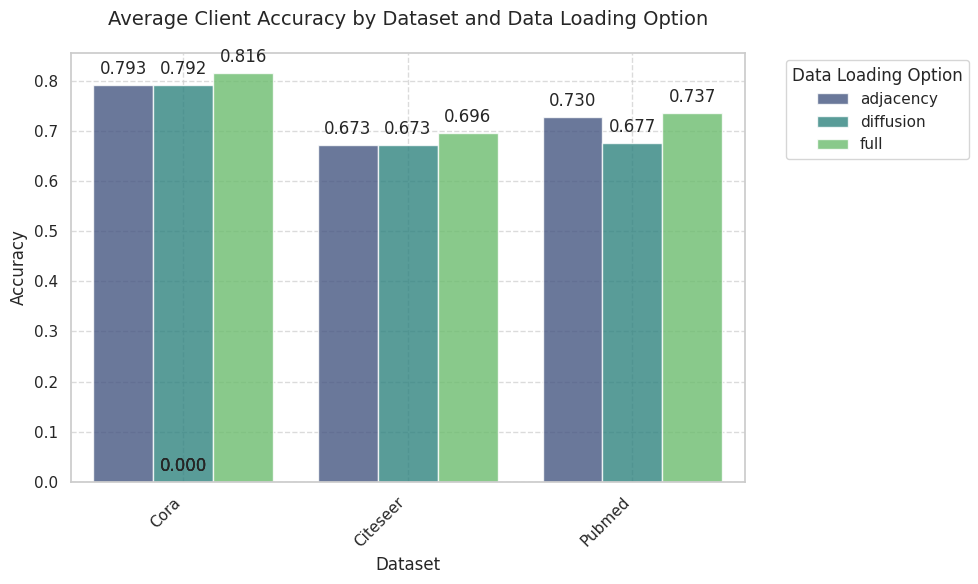

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your DataFrame
# Replace this with your actual CSV or DataFrame load method
df = df_noniid  # or use pd.read_excel(), etc.

# Set plot style
sns.set(style="whitegrid")

# Create a single figure with better aesthetics
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the bar chart with improved styling
sns.barplot(data=df, x='dataset', y='average_client_result', 
            hue='data_loading_option', ax=ax,
            palette='viridis', alpha=0.8)

# Customize the plot
ax.set_title('Average Client Accuracy by Dataset and Data Loading Option', 
             fontsize=14, pad=20)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_xlabel('Dataset', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.7)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Adjust legend
ax.legend(title='Data Loading Option', 
          bbox_to_anchor=(1.05, 1), 
          loc='upper left')

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points')

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()


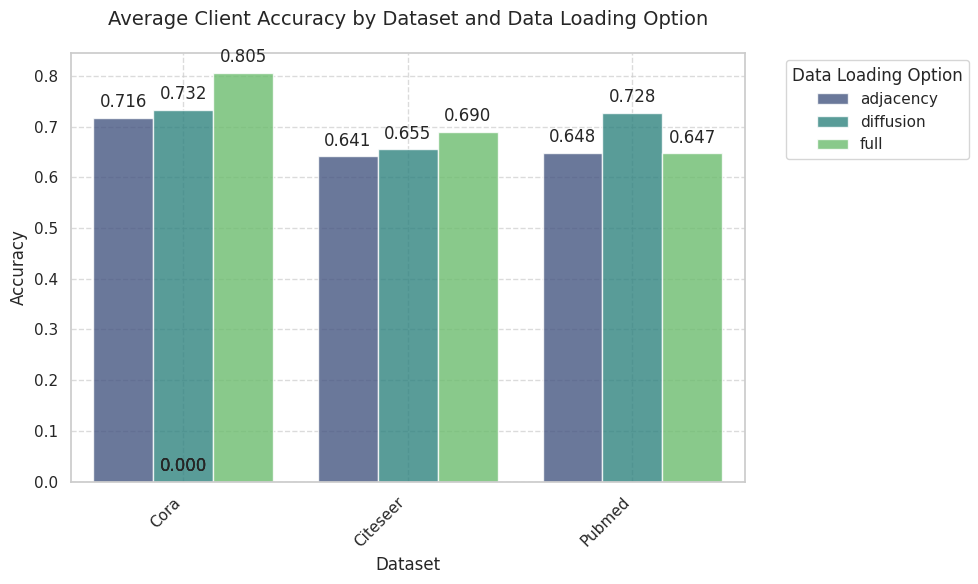

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your DataFrame
# Replace this with your actual CSV or DataFrame load method
df = df_iid  # or use pd.read_excel(), etc.

# Set plot style
sns.set(style="whitegrid")

# Create a single figure with better aesthetics
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the bar chart with improved styling
sns.barplot(data=df, x='dataset', y='average_client_result', 
            hue='data_loading_option', ax=ax,
            palette='viridis', alpha=0.8)

# Customize the plot
ax.set_title('Average Client Accuracy by Dataset and Data Loading Option', 
             fontsize=14, pad=20)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_xlabel('Dataset', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.7)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Adjust legend
ax.legend(title='Data Loading Option', 
          bbox_to_anchor=(1.05, 1), 
          loc='upper left')

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points')

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()
